In [37]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import importlib
import model.model
import model.grid
import model
importlib.reload(model.model)
importlib.reload(model.utils)
importlib.reload(model.grid)

from model.model import QGM
from model.utils import Solver 
from model.grid import Grid

In [45]:
jax.config.update("jax_platform_name", "cpu")

# === Parameter definitions === #
master_key = jax.random.PRNGKey(0)
master_key, key_init, init1, init2 = jax.random.split(master_key, num=4)

params = {
        'nx': 256, 
        'Lx': 2*jnp.pi, 
        'f0': 0.0,
        'kmin': 4.0,
        'kmax': 10.0,
        'kcut': 0.5 * (128 // 2),
        'beta': 1, 
        'mu': 1e-3,
        'nu': 100,
        'dt': 1e-2,
        'k_f': 16.0,        # central forcing wavenumber
        'k_width': 1.5,    # width of the ring
        'epsilon': 1e-3,   #energy input 
        'key':key_init
}

# === Set up model === 
model = QGM(params) 

model.initialize()

In [46]:
model.make_animation(nsteps=10000, frame_interval=100, outname="outputs/qg.gif")

In [40]:
import numpy as _np

# 1. basic model state
print("model.n =", getattr(model, "n", None))
print("beta:", model.parameters.get("beta"))

# 2. psi array diagnostics
psi = _np.array(model.fields["psi"])
print("psi shape", psi.shape)
print("psi min,max,mean:", float(_np.nanmin(psi)), float(_np.nanmax(psi)), float(_np.nanmean(psi)))
print("psi contains NaN/Inf?", _np.isnan(psi).any(), _np.isinf(psi).any())

# 3. grid spacing
print("grid Lx,Ly:", float(model.grid.Lx), float(model.grid.Ly))
print("grid nx,ny:", model.grid.nx, model.grid.ny)
print("grid dx,dy:", getattr(model.grid, "dx", None), getattr(model.grid, "dy", None))

# 4. compute u,v and their stats
from jax.numpy.fft import rfftn, irfftn
from jax import numpy as jnp
zetah = rfftn(_np.array(model.fields["zeta"]), axes=(-2, -1))
psih = -zetah * model.grid.invK2
uh = -1j * model.grid.KY * psih
vh =  1j * model.grid.KX * psih
u = _np.array(irfftn(uh, axes=(-2, -1)).real)
v = _np.array(irfftn(vh, axes=(-2, -1)).real)
print("u min,max,mean:", u.min(), u.max(), u.mean())
print("v min,max,mean:", v.min(), v.max(), v.mean())
print("u,v NaN/Inf?", _np.isnan(u).any(), _np.isinf(u).any(), _np.isnan(v).any(), _np.isinf(v).any())

# 5. U_rms and L_beta computed directly
U_rms = _np.sqrt(0.5 * _np.mean(u**2 + v**2))
beta = float(model.parameters.get("beta", 1.0))
Lbeta = _np.sqrt(U_rms / beta) if beta != 0 else float("nan")
print("U_rms:", U_rms, "Lbeta:", Lbeta)


model.n = 10100
beta: 1
psi shape (256, 256)
psi min,max,mean: -0.08065741509199142 0.0647299736738205 3.4924596548080444e-10
psi contains NaN/Inf? False False
grid Lx,Ly: 6.283185307179586 6.283185307179586
grid nx,ny: 256 256
grid dx,dy: 0.04908738521234052 0.04908738521234052
u min,max,mean: -0.8212987 0.89079046 0.0
v min,max,mean: -0.86802614 0.96848637 -2.1600499e-10
u,v NaN/Inf? False False False False
U_rms: 0.2123117 Lbeta: 0.46077293


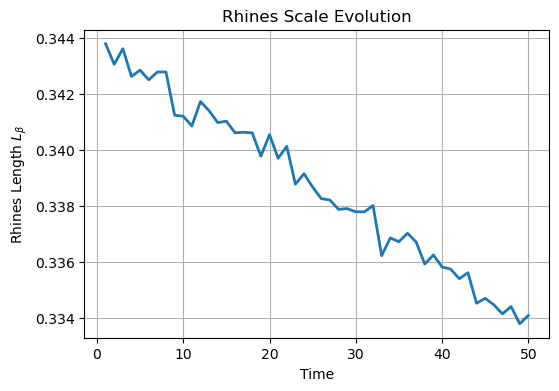

In [41]:
def plot_rhines_length(model, nsteps, interval=100):
    """
    Step the model and plot Rhines scale vs time.
    """
    L_list = []
    t_list = []

    for i in range(nsteps):
        model.steps(interval)
        L = model.compute_rhines_length()
        L_list.append(L)
        t_list.append((i+1) * interval * model.dt)

    plt.figure(figsize=(6,4))
    plt.plot(t_list, L_list, lw=2)
    plt.xlabel("Time")
    plt.ylabel("Rhines Length $L_\\beta$")
    plt.title("Rhines Scale Evolution")
    plt.grid(True)
    plt.show()

plot_rhines_length(model, nsteps=50, interval=100)

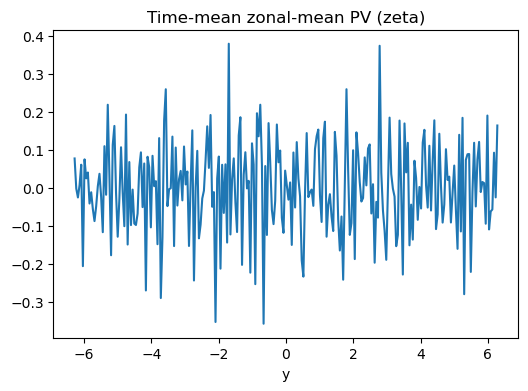

In [42]:
import numpy as _np
# equilibrate
model.steps(2000)   # adjust longer if needed

ny = model.grid.ny
qacc = _np.zeros((ny,))
navg = 2000
for i in range(navg):
    model.steps(1)
    q = _np.array(model.fields["zeta"])   # vorticity = PV in barotropic
    qacc += q.mean(axis=1)    # zonal mean (average over x)
q_mean = qacc / float(navg)

y = _np.linspace(-model.grid.Ly, model.grid.Ly, model.grid.ny)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(y, q_mean)
plt.xlabel("y"); plt.title("Time-mean zonal-mean PV (zeta)")
plt.show()